In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

**Pametros de entrada del sistema**

In [2]:
N_palas= 3         # Número de palas
m=0.420            # Masa total [kg]
 
R=0.22869          # Radio exterior del rotor [m]
r0=0.04776         # Radio inicio de pala [m]
c=0.0204           # Cuerda de la pala [m]
 
rho=1.225         # Densidad del aire [kg/m³]
g=9.81            # Gravedad [m/s²]
W=m*g             # Peso total [N]

**Tabla aerodinàmica-Perfil NACA 0012**

In [5]:
alpha=np.arange(-3, 15.5, 0.5)         # [deg]  (-3 : 0.5 : 15)
Cl=2*np.pi*np.radians(alpha)          # Coeficiente de sustentación lineal
Cd=0.008+0.01*(Cl - 0)** 2            # Coeficiente de arrastre (polar parabólica)
 
alpha_deg=alpha.copy()
CL=Cl.copy()
CD=Cd.copy()
eficiencia=CL/CD

**Datos de salida**

In [6]:
Vd_sensor=np.linspace(0.5, 50, 200)      # Rango de velocidades de descenso [m/s]
 
n_alpha=len(alpha_deg)
n_Vd=len(Vd_sensor)
 
T_matrix=np.zeros((n_alpha, n_Vd))       # Empuje [N]
Om=np.zeros((n_alpha, n_Vd))             # Velocidad angular [rad/s]
 
# Rangos de velocidad
R3r0=R**3-r0**3
R4r0=R**4-r0**4
 
for i in range(n_alpha):
    for j in range(n_Vd):
        # Ecuación A
        Om[i, j] = (4 * Vd_sensor[j] * CL[i] * R3r0) / (3 * CD[i] * R4r0)       #Ecuaciones a partir de las notas
        # Ecuación B
        T_matrix[i, j] = (N_palas / 6) * rho * c * CL[i] * Om[i, j]**2 * R3r0   #Ecuaciones a partir de las notas

**Equilibrio para la velocidad de descenso**

In [7]:
K_eq=(16*N_palas/54)*rho*c*(R3r0**3/R4r0**2)                       #Constantes de la ecuacion para que no estorben
Vd_eq=np.zeros(n_alpha)
 
print(f"{'alpha [°]':<12} {'CL':<8} {'CD':<8} {'Vd_eq [m/s]':<18} {'Régimen'}")  #Imprimimos la tabla del pitch y la velocidad de equilibrio 
print("-" * 65)
 
for i in range(n_alpha):
    Vd_eq[i] = np.sqrt(W/ (K_eq*(CL[i]**3/CD[i]**2)))                            #Susituimos A en B e igualamos al W
 
    if Vd_eq[i] > 8:
        interp = 'Caída rápida'
    elif Vd_eq[i] > 3:
        interp = 'Descenso moderado'
    else:
        interp = 'Descenso lento / estable'
 
    print(f"{alpha_deg[i]:<12.0f} {CL[i]:<8.3f} {CD[i]:<8.5f} {Vd_eq[i]:<18.3f} {interp}")

alpha [°]    CL       CD       Vd_eq [m/s]        Régimen
-----------------------------------------------------------------
-3           -0.329   0.00908  nan                Descenso lento / estable
-2           -0.274   0.00875  nan                Descenso lento / estable
-2           -0.219   0.00848  nan                Descenso lento / estable
-2           -0.164   0.00827  nan                Descenso lento / estable
-1           -0.110   0.00812  nan                Descenso lento / estable
-0           -0.055   0.00803  nan                Descenso lento / estable
0            0.000    0.00800  inf                Caída rápida
0            0.055    0.00803  18.024             Caída rápida
1            0.110    0.00812  6.444              Descenso moderado
2            0.164    0.00827  3.573              Descenso moderado
2            0.219    0.00848  2.379              Descenso lento / estable
2            0.274    0.00875  1.757              Descenso lento / estable
3            0

C:\Users\Usuario\AppData\Local\Temp\ipykernel_1932\3306227393.py:8: RuntimeWarning: invalid value encountered in sqrt
  Vd_eq[i] = np.sqrt(W/ (K_eq*(CL[i]**3/CD[i]**2)))                            #Susituimos A en B e igualamos al W
C:\Users\Usuario\AppData\Local\Temp\ipykernel_1932\3306227393.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  Vd_eq[i] = np.sqrt(W/ (K_eq*(CL[i]**3/CD[i]**2)))                            #Susituimos A en B e igualamos al W


Es la unica velocidad de descenso para un \alpha en que el peso se equilibra, el rotor no se acelera ni se frena y esistema se estable en el tiempo.
En el caso que Vd<Veq T<W por lo que el sistema comienza acelerar hacia abajo
En el caso Vd>Veq Entra más flujo al rotor el sistema tiene mas sustentacion T>W
Es la velocidad terminal del sistema, para mantener el giro estable

**Posible logica de control**

In [8]:
e    = 0.001    # Tolerancia
Vobj = 0.1      # Velocidad objetivo [m/s]
 
print("\n--- Lógica de control ---")
for i in range(len(Vd_eq)):
    wr = 'aumentar pitch' if Vd_eq[i] - Vobj > e else 'disminuir pitch'
    print(f"alpha = {alpha_deg[i]:<8.2f} | Vd_eq = {Vd_eq[i]:<8.3f} | acción = {wr}")


--- Lógica de control ---
alpha = -3.00    | Vd_eq = nan      | acción = disminuir pitch
alpha = -2.50    | Vd_eq = nan      | acción = disminuir pitch
alpha = -2.00    | Vd_eq = nan      | acción = disminuir pitch
alpha = -1.50    | Vd_eq = nan      | acción = disminuir pitch
alpha = -1.00    | Vd_eq = nan      | acción = disminuir pitch
alpha = -0.50    | Vd_eq = nan      | acción = disminuir pitch
alpha = 0.00     | Vd_eq = inf      | acción = aumentar pitch
alpha = 0.50     | Vd_eq = 18.024   | acción = aumentar pitch
alpha = 1.00     | Vd_eq = 6.444    | acción = aumentar pitch
alpha = 1.50     | Vd_eq = 3.573    | acción = aumentar pitch
alpha = 2.00     | Vd_eq = 2.379    | acción = aumentar pitch
alpha = 2.50     | Vd_eq = 1.757    | acción = aumentar pitch
alpha = 3.00     | Vd_eq = 1.387    | acción = aumentar pitch
alpha = 3.50     | Vd_eq = 1.148    | acción = aumentar pitch
alpha = 4.00     | Vd_eq = 0.984    | acción = aumentar pitch
alpha = 4.50     | Vd_eq = 0.867    |

**Graficas**

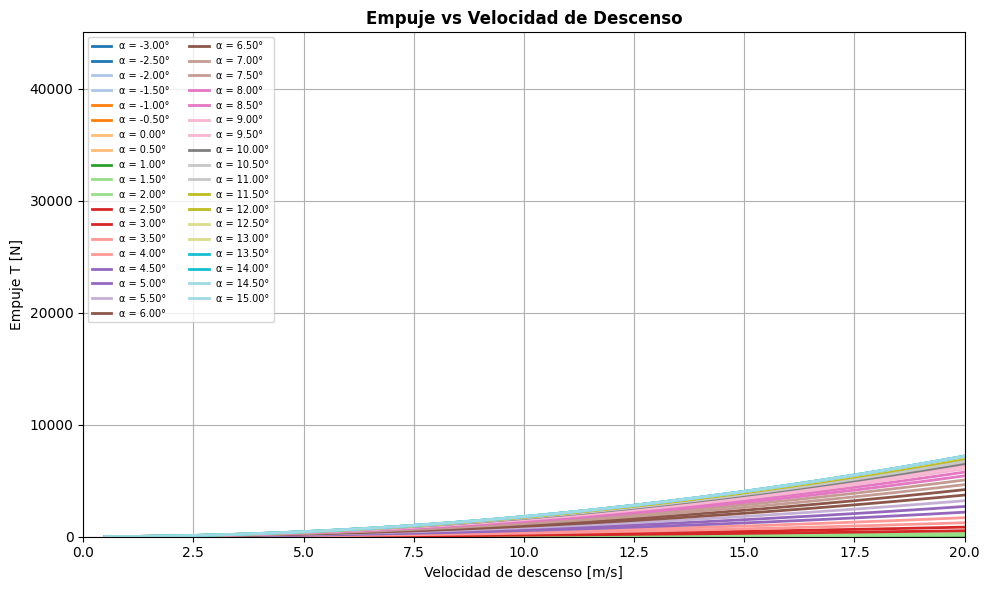

In [9]:
colores = plt.cm.tab20(np.linspace(0, 1, n_alpha))
 
# 1. Empuje vs Velocidad de descenso
fig1, ax1 = plt.subplots(figsize=(10, 6))
for i in range(n_alpha):
    ax1.plot(Vd_sensor, T_matrix[i, :], linewidth=2, color=colores[i],
             label=f'α = {alpha_deg[i]:.2f}°')
ax1.set_xlabel('Velocidad de descenso [m/s]', fontsize=10)
ax1.set_ylabel('Empuje T [N]', fontsize=10)
ax1.set_title('Empuje vs Velocidad de Descenso', fontweight='bold')
ax1.legend(loc='upper left', fontsize=7, ncol=2)
ax1.set_xlim([0, 20])
ax1.set_ylim([0, T_matrix.max()])
ax1.grid(True)
plt.tight_layout()

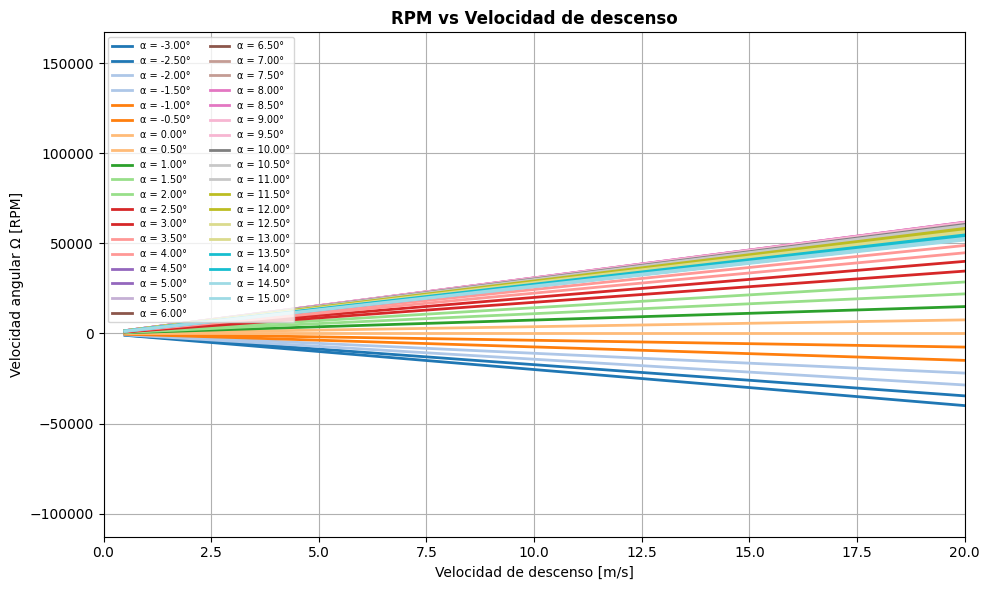

In [10]:
# 2. RPM vs Velocidad de descenso
fig2, ax2 = plt.subplots(figsize=(10, 6))
for i in range(n_alpha):
    RPM_line = Om[i, :] * 60 / (2 * np.pi)
    ax2.plot(Vd_sensor, RPM_line, linewidth=2, color=colores[i],
             label=f'α = {alpha_deg[i]:.2f}°')
ax2.set_xlabel('Velocidad de descenso [m/s]', fontsize=10)
ax2.set_ylabel('Velocidad angular Ω [RPM]', fontsize=10)
ax2.set_title('RPM vs Velocidad de descenso', fontweight='bold')
ax2.legend(loc='upper left', fontsize=7, ncol=2)
ax2.set_xlim([0, 20])
ax2.grid(True)
plt.tight_layout()

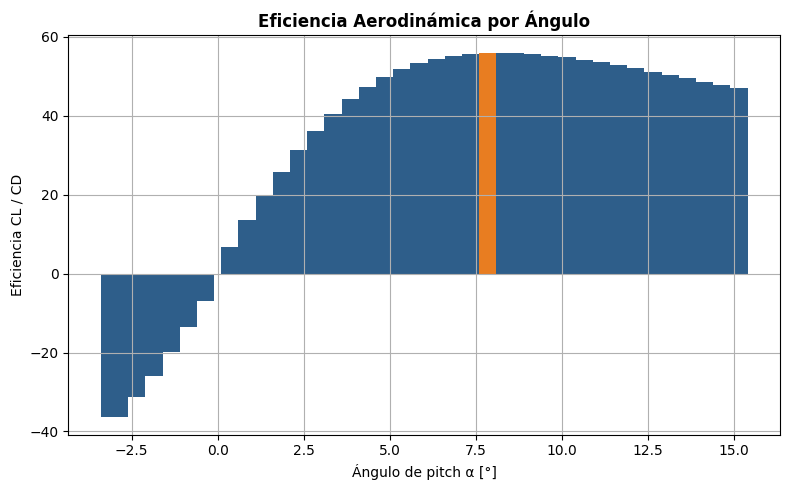

In [11]:
# 3. Eficiencia aerodinámica por ángulo
fig3, ax3 = plt.subplots(figsize=(8, 5))
bars = ax3.bar(alpha_deg, eficiencia, color=[0.18, 0.37, 0.54], edgecolor='none')
idx_max = np.argmax(eficiencia)
bars[idx_max].set_facecolor([0.91, 0.49, 0.13])
ax3.set_xlabel('Ángulo de pitch α [°]', fontsize=10)
ax3.set_ylabel('Eficiencia CL / CD', fontsize=10)
ax3.set_title('Eficiencia Aerodinámica por Ángulo', fontweight='bold')
ax3.grid(True)
plt.tight_layout()

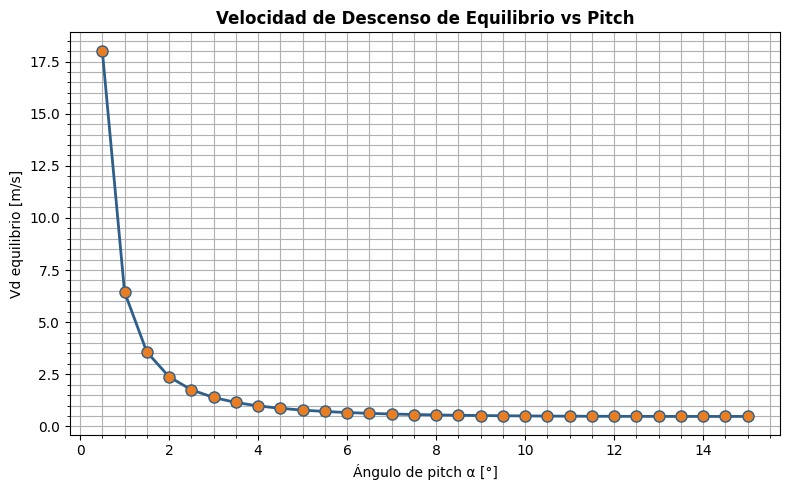

In [12]:
# 4. Velocidad de descenso de equilibrio vs Pitch
fig4, ax4=plt.subplots(figsize=(8, 5))
ax4.plot(alpha_deg, Vd_eq, 'o-', linewidth=2,color=[0.18, 0.37, 0.54], markersize=8,markerfacecolor=[0.91, 0.49, 0.13])
ax4.set_xlabel('Ángulo de pitch α [°]', fontsize=10)
ax4.set_ylabel('Vd equilibrio [m/s]', fontsize=10)
ax4.set_title('Velocidad de Descenso de Equilibrio vs Pitch', fontweight='bold')
ax4.grid(True, which='both')
ax4.minorticks_on()
plt.tight_layout()

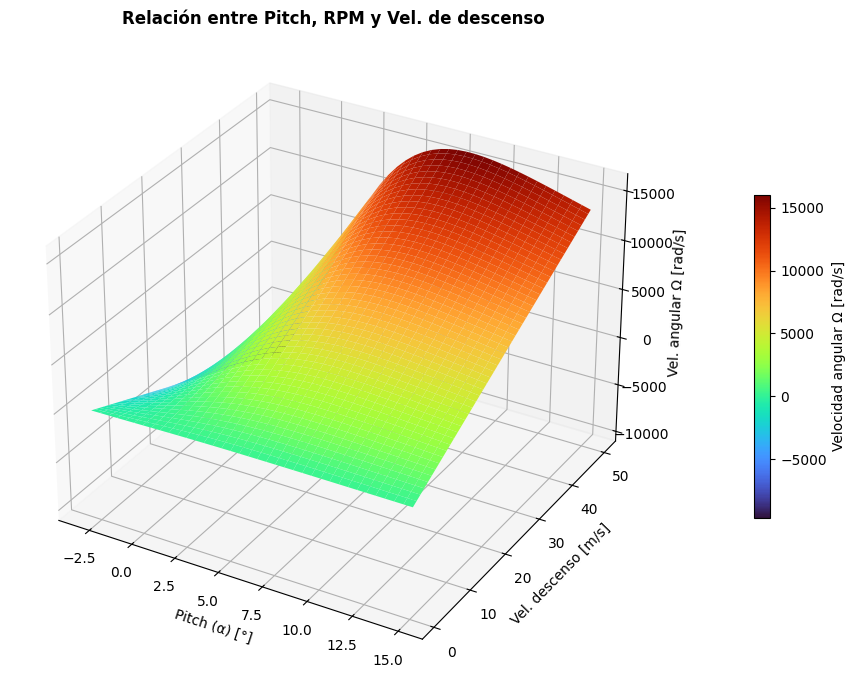

In [13]:
# 5. Superficie 3D: RPM, Pitch, Velocidad de descenso
Alpha_mesh, Vd_mesh = np.meshgrid(alpha_deg, Vd_sensor)   # shapes: (n_Vd, n_alpha)
Om_mesh = Om.T                                            # transpose → (n_Vd, n_alpha)
 
fig5= plt.figure(figsize=(10,7))
ax5=fig5.add_subplot(111, projection='3d')
surf=ax5.plot_surface(Alpha_mesh, Vd_mesh, Om_mesh, cmap='turbo', linewidth=0, antialiased=True)
ax5.set_xlabel('Pitch (α) [°]')
ax5.set_ylabel('Vel. descenso [m/s]')
ax5.set_zlabel('Vel. angular Ω [rad/s]')
ax5.set_title('Relación entre Pitch, RPM y Vel. de descenso', fontweight='bold')
cb = fig5.colorbar(surf, ax=ax5, shrink=0.5, pad=0.1)
cb.set_label('Velocidad angular Ω [rad/s]')
plt.tight_layout()
 
plt.show()